In [1]:
!pip install transformers torch nltk emoji matplotlib seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 10.1 MB/s eta 0:00:00


In [2]:
import pandas as pd
import re
import emoji
import nltk
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import pipeline
from nltk.corpus import stopwords


In [3]:
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

## **Social Media Comments**

In [4]:
data = {
    "comment": [
        "I love this app! It works perfectly 😍",
        "This update is terrible. I hate it 😡",
        "Not bad, but could be improved.",
        "I am very sad after using this feature 😢",
        "Amazing experience! Totally satisfied 😊",
        "Worst service ever! Very disappointing 😠",
        "I'm scared about my data privacy 😨",
        "This is okay, nothing special.",
        "I feel happy and joyful using this platform 🎉",
        "I regret downloading this app",

        "Great performance and smooth interface 👍",
        "This app crashes a lot, very annoying 😤",
        "Satisfied with the overall experience 🙂",
        "Feeling angry because of too many bugs 😡",
        "Excellent update, well done developers 👏",
        "This feature makes me sad 😞",
        "I love the new design, looks beautiful ❤️",
        "Not impressed, expected more 😐",
        "Terrible customer support experience 😠",
        "I feel safe using this app 😊",

        "The app is fast and reliable ⚡",
        "Very poor experience, not recommended 😒",
        "Neutral feelings about this update",
        "I am happy with the service provided 😄",
        "This makes me frustrated every time 😤",
        "Amazing speed and performance 🚀",
        "The interface is confusing and bad 😕",
        "It works fine for basic use",
        "I am worried about security issues 😟",
        "Totally love this feature 😍",

        "Nothing special, just an average app",
        "I hate the latest update 😡",
        "This app makes my life easier 😊",
        "Disappointed after using it 😞",
        "Great effort by the development team 👌",
        "This app wastes too much time 😠",
        "I feel joyful using this app 🎉",
        "Not satisfied with performance 😐",
        "Very smooth and easy to use 👍",
        "It scares me how much data it takes 😨",

        "The design looks modern and clean 😍",
        "Bad experience overall 😡",
        "I feel neutral about this application",
        "Excellent usability and features 😄",
        "The app keeps freezing 😤",
        "Love the simplicity of this app ❤️",
        "It feels outdated and boring 😒",
        "Average performance, nothing new",
        "I am happy but it needs improvements 🙂",
        "I regret updating this app 😞",

        "Fantastic app with useful features 🌟",
        "Very annoying notifications 😡",
        "This app does what it promises",
        "Feeling sad because of poor optimization 😢",
        "Highly satisfied with the service 😊",
        "Worst update so far 😠",
        "I feel confident using this platform 👍",
        "It’s okay, not too good",
        "The experience makes me angry 😤",
        "This app makes me happy 😍",

        "Decent app for daily use",
        "I dislike the new interface 😒",
        "Very good performance overall 😊",
        "It disappoints me every time 😞",
        "I feel safe and comfortable using it 🙂",
        "Terrible lag issues 😡",
        "Good but needs improvement",
        "I am scared about future updates 😨",
        "Happy with customer support 😄",
        "I will uninstall this app 😠"
    ]
}

df = pd.DataFrame(data)
df.head()


,comment
0,I love this app! It works perfectly 😍
1,This update is terrible. I hate it 😡
2,"Not bad, but could be improved."
3,I am very sad after using this feature 😢
4,Amazing experience! Totally satisfied 😊


# **Text** **Preprocessing**

In [12]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)      # remove URLs
    text = re.sub(r"@\w+", "", text)         # remove mentions
    text = re.sub(r"#\w+", "", text)         # remove hashtags
    text = emoji.demojize(text)               # convert emojis to text
    text = re.sub(r"[^a-z\s]", "", text)     # remove symbols
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df["clean_comment"] = df["comment"].apply(clean_text)
df


,comment,clean_comment,sentiment,emotion
0,I love this app! It works perfectly 😍,love app works perfectly smilingfacewithhearteyes,POSITIVE,joy
1,This update is terrible. I hate it 😡,update terrible hate enragedface,NEGATIVE,anger
2,"Not bad, but could be improved.",bad could improved,NEGATIVE,neutral
3,I am very sad after using this feature 😢,sad using feature cryingface,NEGATIVE,sadness
4,Amazing experience! Totally satisfied 😊,amazing experience totally satisfied smilingfa...,POSITIVE,joy
...,...,...,...,...
65,Terrible lag issues 😡,terrible lag issues enragedface,NEGATIVE,anger
66,Good but needs improvement,good needs improvement,POSITIVE,neutral
67,I am scared about future updates 😨,scared future updates fearfulface,NEGATIVE,fear
68,Happy with customer support 😄,happy customer support grinningfacewithsmiling...,POSITIVE,joy


# **Load Pretrained Models**

**Sentiment** **Model**

In [6]:
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Device set to use cpu


**Emotion Model**

In [7]:
emotion_pipeline = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    top_k=1
)


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/329M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/329M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/294 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Device set to use cpu


# **Sentiment Prediction**

In [8]:
df["sentiment"] = df["clean_comment"].apply(
    lambda x: sentiment_pipeline(x)[0]["label"]
)
df


,comment,clean_comment,sentiment
0,I love this app! It works perfectly 😍,love app works perfectly smilingfacewithhearteyes,POSITIVE
1,This update is terrible. I hate it 😡,update terrible hate enragedface,NEGATIVE
2,"Not bad, but could be improved.",bad could improved,NEGATIVE
3,I am very sad after using this feature 😢,sad using feature cryingface,NEGATIVE
4,Amazing experience! Totally satisfied 😊,amazing experience totally satisfied smilingfa...,POSITIVE
...,...,...,...
65,Terrible lag issues 😡,terrible lag issues enragedface,NEGATIVE
66,Good but needs improvement,good needs improvement,POSITIVE
67,I am scared about future updates 😨,scared future updates fearfulface,NEGATIVE
68,Happy with customer support 😄,happy customer support grinningfacewithsmiling...,POSITIVE


# **Emotion Prediction**

In [9]:
df["emotion"] = df["clean_comment"].apply(
    lambda x: emotion_pipeline(x)[0][0]["label"]
)
df


,comment,clean_comment,sentiment,emotion
0,I love this app! It works perfectly 😍,love app works perfectly smilingfacewithhearteyes,POSITIVE,joy
1,This update is terrible. I hate it 😡,update terrible hate enragedface,NEGATIVE,anger
2,"Not bad, but could be improved.",bad could improved,NEGATIVE,neutral
3,I am very sad after using this feature 😢,sad using feature cryingface,NEGATIVE,sadness
4,Amazing experience! Totally satisfied 😊,amazing experience totally satisfied smilingfa...,POSITIVE,joy
...,...,...,...,...
65,Terrible lag issues 😡,terrible lag issues enragedface,NEGATIVE,anger
66,Good but needs improvement,good needs improvement,POSITIVE,neutral
67,I am scared about future updates 😨,scared future updates fearfulface,NEGATIVE,fear
68,Happy with customer support 😄,happy customer support grinningfacewithsmiling...,POSITIVE,joy


# **Final Output Table**

In [ ]:
df[["comment", "sentiment", "emotion"]]


,comment,sentiment,emotion
0,I love this app! It works perfectly 😍,POSITIVE,joy
1,This update is terrible. I hate it 😡,NEGATIVE,anger
2,"Not bad, but could be improved.",NEGATIVE,neutral
3,I am very sad after using this feature 😢,NEGATIVE,sadness
4,Amazing experience! Totally satisfied 😊,POSITIVE,joy
...,...,...,...
65,Terrible lag issues 😡,NEGATIVE,anger
66,Good but needs improvement,POSITIVE,neutral
67,I am scared about future updates 😨,NEGATIVE,fear
68,Happy with customer support 😄,POSITIVE,joy


**Visualization – Sentiment Distribution**

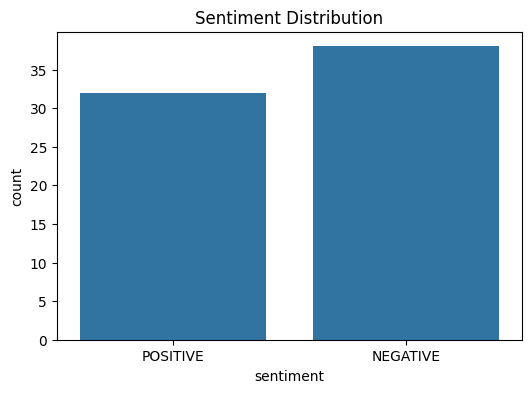

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["sentiment"])
plt.title("Sentiment Distribution")
plt.show()


**Visualization – Emotion Distribution**

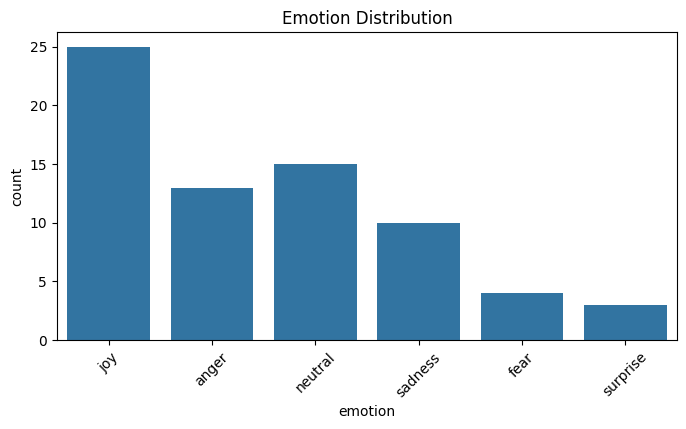

In [11]:
plt.figure(figsize=(8,4))
sns.countplot(x=df["emotion"])
plt.title("Emotion Distribution")
plt.xticks(rotation=45)
plt.show()
